# Sink Node Characterisation — Which Nodes Become Sinks? (GRIT)

**Hypothesis H2:** Attention sinks preferentially form on structurally distinguished nodes.

We run inference on trained GRIT models to extract per-node sink scores
and correlate with degree, centrality, and spectral position.

In [18]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr
import yaml
import networkx as nx
from tqdm import tqdm
from torch_geometric.utils import degree, get_laplacian, to_scipy_sparse_matrix
from torch_geometric.data import Data

from src.model import InstrumentedGRIT
from src.datasets import get_dataloaders, DATASET_INFO, compute_spectral_properties
from src.metrics import compute_sink_scores

OUTPUTS_DIR = '../outputs'
FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [19]:
def load_experiment(experiment_id, device):
    config_path = os.path.join(OUTPUTS_DIR, experiment_id, 'config.yaml')
    with open(config_path) as f:
        config = yaml.safe_load(f)
    dataset_info = DATASET_INFO[config['data']['dataset']].copy()
    vnode_cfg = config.get('vnode', {})
    if vnode_cfg.get('enabled', False) and dataset_info.get('num_node_types') is not None:
        dataset_info['num_node_types'] = dataset_info['num_node_types'] + 1
        dataset_info['num_edge_types'] = dataset_info['num_edge_types'] + 1
    model = InstrumentedGRIT(config, dataset_info).to(device)
    model.load_state_dict(torch.load(
        os.path.join(OUTPUTS_DIR, experiment_id, 'best_model.pt'),
        map_location=device, weights_only=True))
    model.eval()
    return model, config, dataset_info

## 1. Extract per-node sink scores and structural properties

In [20]:
@torch.no_grad()
def extract_sink_data(model, config, device, max_graphs=200):
    _, _, test_loader, _ = get_dataloaders(config)
    model.eval()
    all_graphs = []
    graphs_done = 0
    for batch in tqdm(test_loader, desc='Extracting sink data'):
        if graphs_done >= max_graphs:
            break
        batch = batch.to(device)
        _ = model(batch, collect_diagnostics=True)
        batch_ids = model.layer_data[0]['batch']
        unique_graphs = batch_ids.unique()
        for g_idx, g_id in enumerate(unique_graphs):
            if graphs_done >= max_graphs:
                break
            graph_mask = (batch_ids == g_id)
            num_nodes_g = graph_mask.sum().item()
            node_indices = torch.where(graph_mask)[0]
            g_edges = batch.edge_index[:, batch.batch[batch.edge_index[0]] == g_id]
            local_map = {int(n): i for i, n in enumerate(node_indices)}
            local_edges = [[local_map[s], local_map[d]] for s, d in g_edges.t().tolist()
                           if s in local_map and d in local_map]
            local_ei = torch.tensor(local_edges).t() if local_edges else torch.zeros(2, 0, dtype=torch.long)
            local_src = local_ei[0] if local_ei.size(1) > 0 else torch.zeros(0, dtype=torch.long)
            deg = degree(local_src, num_nodes=num_nodes_g)
            G = nx.Graph()
            G.add_nodes_from(range(num_nodes_g))
            for s, d in zip(local_ei[0].tolist(), local_ei[1].tolist()):
                G.add_edge(s, d)
            centrality = nx.betweenness_centrality(G)
            cent_array = np.array([centrality.get(i, 0.0) for i in range(num_nodes_g)])

            spectral = compute_spectral_properties(Data(edge_index=local_ei, num_nodes=num_nodes_g))

            graph_data = {
                'num_nodes': num_nodes_g, 'degree': deg.numpy(),
                'centrality': cent_array, 'lambda_2': spectral['lambda_2'],
                'sink_scores_by_layer': {},
            }
            for layer_idx in range(len(model.attn_weights)):
                attn_full = model.attn_weights[layer_idx]
                if attn_full is not None and g_idx < attn_full.size(0):
                    attn_g = attn_full[g_idx, :, :num_nodes_g, :num_nodes_g]
                    sink_data = compute_sink_scores(attn_g)
                    graph_data['sink_scores_by_layer'][layer_idx + 1] = sink_data['sink_score_per_node'].numpy()
                    graph_data[f'max_sink_score_layer_{layer_idx + 1}'] = sink_data['max_sink_score']
            all_graphs.append(graph_data)
            graphs_done += 1
    print(f'Collected data for {len(all_graphs)} graphs')
    return all_graphs

In [21]:
experiments_to_analyse = [
    ('zinc-grit', 'ZINC (no VNode, ~23 nodes)'),
    ('peptides-grit', 'Peptides (no VNode, ~150 nodes)'),
]

all_sink_data = {}
for eid, desc in experiments_to_analyse:
    if not os.path.exists(os.path.join(OUTPUTS_DIR, eid, 'best_model.pt')):
        print(f'Skipping {eid} — not trained yet')
        continue
    print(f'\n=== {desc} ===')
    model, config, _ = load_experiment(eid, device)
    all_sink_data[eid] = {'graphs': extract_sink_data(model, config, device),
                           'num_layers': model.num_layers, 'desc': desc}
    del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None


=== ZINC (no VNode, ~23 nodes) ===
  Loading cached PE for zinc/train from data/pe_cache/zinc_train_rrwp21.pt
  Loading cached PE for zinc/val from data/pe_cache/zinc_val_rrwp21.pt
  Loading cached PE for zinc/test from data/pe_cache/zinc_test_rrwp21.pt


Extracting sink data:  22%|██▏       | 7/32 [00:07<00:27,  1.10s/it]

Collected data for 200 graphs
Skipping peptides-grit — not trained yet


## 2. Fig 5: Sink Score vs Structural Properties

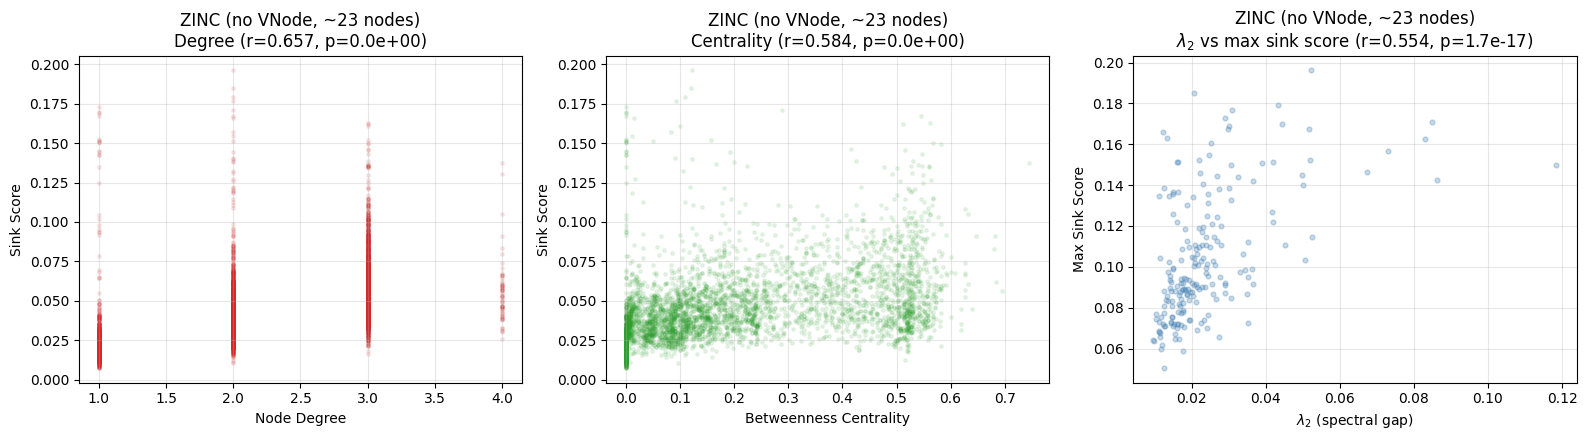

In [23]:
n_rows = len(all_sink_data)
if n_rows == 0:
    print('No data available yet.')
else:
    fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    for row, (eid, data) in enumerate(all_sink_data.items()):
        graphs = data['graphs']
        last_layer = data['num_layers']
        desc = data['desc']

        degrees, sink_scores = [], []
        cent_vals, sink_scores_c = [], []
        lambda2_vals, max_sink_vals = [], []

        for g in graphs:
            if last_layer not in g['sink_scores_by_layer']:
                continue
            scores = g['sink_scores_by_layer'][last_layer]
            degrees.extend(g['degree'].tolist())
            sink_scores.extend(scores.tolist())
            cent_vals.extend(g['centrality'].tolist())
            sink_scores_c.extend(scores.tolist())

            ms_key = f'max_sink_score_layer_{last_layer}'
            if ms_key in g and not np.isnan(g['lambda_2']):
                lambda2_vals.append(g['lambda_2'])
                max_sink_vals.append(g[ms_key])

        # Col 0: Degree vs sink score (per-node)
        xvals, yvals = np.array(degrees), np.array(sink_scores)
        r, p = spearmanr(xvals, yvals)
        axes[row, 0].scatter(xvals, yvals, alpha=0.1, s=6, color='tab:red')
        axes[row, 0].set_xlabel('Node Degree')
        axes[row, 0].set_ylabel('Sink Score')
        axes[row, 0].set_title(f'{desc}\nDegree (r={r:.3f}, p={p:.1e})')
        axes[row, 0].grid(True, alpha=0.3)

        # Col 1: Centrality vs sink score (per-node)
        xvals, yvals = np.array(cent_vals), np.array(sink_scores_c)
        r, p = spearmanr(xvals, yvals)
        axes[row, 1].scatter(xvals, yvals, alpha=0.1, s=6, color='tab:green')
        axes[row, 1].set_xlabel('Betweenness Centrality')
        axes[row, 1].set_ylabel('Sink Score')
        axes[row, 1].set_title(f'{desc}\nCentrality (r={r:.3f}, p={p:.1e})')
        axes[row, 1].grid(True, alpha=0.3)

        # Col 2: Spectral gap vs max sink score (per-graph)
        xvals, yvals = np.array(lambda2_vals), np.array(max_sink_vals)
        r, p = spearmanr(xvals, yvals)
        axes[row, 2].scatter(xvals, yvals, alpha=0.3, s=12, color='steelblue')
        axes[row, 2].set_xlabel('$\\lambda_2$ (spectral gap)')
        axes[row, 2].set_ylabel('Max Sink Score')
        axes[row, 2].set_title(f'{desc}\n$\\lambda_2$ vs max sink score (r={r:.3f}, p={p:.1e})')
        axes[row, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig5_sink_characterisation.pdf'), bbox_inches='tight', dpi=150)
    plt.show()